# NOAA Storm Events Weather Data Workbook
The dataset we are working with in this notebook comes from the [NOAA Storm Events Database](https://www.ncdc.noaa.gov/stormevents/), specifically the **StormEvents_Details** files. We will begin by exploring the raw data.

We first walk you through the steps taken in Python to clean and format the data so that it resembles the structure of the power outage dataset. This alignment allows you to apply similar analysis techniques—such as creating histograms or performing K-means clustering. The dataset includes all significant storm events since 2016. However, not all of these events are severe enough to cause power outages. You will need to define your own criteria for identifying the most impactful events, justify your choices, and then either replicate our analysis or create your own.

This notebook is designed to encourage critical thinking about data cleaning and analysis. You are invited to build on the techniques demonstrated here or explore new directions. One possible extension is to combine this dataset with the power outage data to investigate how closely storm timing and location align with outages—though doing this well will require careful data alignment.

## Guidance for Part 3 of Your Project

- Begin by using the cells in this notebook to explore, clean, and format the storm data so it resembles the outage dataset.  
  Then try the histogram and K-means clustering exercises on the **unfiltered** storm dataset. Reflect on how useful (or not) the results are.

- Consider whether filtering by event type, severity, or location improves your ability to extract meaningful patterns.

- Choose analytical methods (e.g., histograms, clustering, etc.) to identify trends in the storm data. Use these trends to evaluate whether weather-related events explain the patterns you observed in the outage data.

- **Fallback strategy**: If time is limited, you may skip the notebook-based analysis and instead use anecdotal evidence (e.g., news reports) of major storms and related outages to support your conclusions. Be sure to also explore non-weather-related causes of power outages if you take this anecdotal approach, to avoid motivated reasoning—that is, the tendency to seek only evidence that supports a preferred hypothesis. Finally, outline how more data-intensive techniques could be used in future work to deepen your analysis.



In [53]:
# Import python packages
import os
import sys
import math
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The raw data from NOAA is organized into one CSV file per year. 
A CSV (Comma-Separated Values) file is a plain text format where each 
row represents a record, and each column is separated by a comma.

Unfortunately, some of these files are corrupted or inconsistently formatted, 
which can cause errors when attempting to load the data. To handle this, we need 
to identify and filter out the problematic rows or files.

The following cell reads in the yearly files and removes any entries with 
formatting issues, allowing us to work with a clean and consistent dataset.



In [54]:
#Check what diretory you are in. 
!pwd
#List the data you need for this noteboot. The data sits in global/cfs/cdirs/m4388/Project3/Data/StromData
!ls ../Data/StormData
#If the command above gives a files not found type error, you will need to adjust the path in the cell below. 

/global/cfs/cdirs/m4388/Project3/anatomy_of_a_power_outage
'Details '
 StormEvents_details-ftp_v1.0_d2016_c20250520.csv
 StormEvents_details-ftp_v1.0_d2017_c20250520.csv
 StormEvents_details-ftp_v1.0_d2018_c20250520.csv
 StormEvents_details-ftp_v1.0_d2019_c20250520.csv
 StormEvents_details-ftp_v1.0_d2021_c20250520.csv
 StormEvents_details-ftp_v1.0_d2022_c20250721.csv
 StormEvents_locations-ftp_v1.0_d2016_c20250401.csv
 StormEvents_locations-ftp_v1.0_d2017_c20250401.csv
 StormEvents_locations-ftp_v1.0_d2018_c20250520.csv
 StormEvents_locations-ftp_v1.0_d2019_c20250520.csv
 StormEvents_locations-ftp_v1.0_d2020_c20250702.csv
 StormEvents_locations-ftp_v1.0_d2021_c20250520.csv
 StormEvents_locations-ftp_v1.0_d2022_c20250520.csv
 tl_2022_us_county
 Untitled.ipynb
 Weather_locations.ipynb


In [55]:
import csv
# Define the list of (year, suffix) for each file
details_files = [
    ("2016", "20250520"),
    ("2017", "20250520"),
    ("2018", "20250520"),
    ("2019", "20250520"),
    ("2021", "20250520"),
    ("2022", "20250721"),
]

# Function to scan a file for malformed rows before reading
def find_bad_rows(filename, max_errors=10):
    bad_rows = []
    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        try:
            header = next(reader)
        except Exception as e:
            print(f" Failed to read header in {filename}: {e}")
            return bad_rows
        
        num_columns = len(header)
        for i, row in enumerate(reader, start=2):
            if len(row) != num_columns:
                bad_rows.append((i, row))
                print(f" {filename} - Bad row at line {i} (got {len(row)} columns): {row}")
                if len(bad_rows) >= max_errors:
                    print(f"...stopping after {max_errors} errors.")
                    break
    return bad_rows

# Read each file, report issues, and safely collect DataFrames
details_dfs = []

for year, suffix in details_files:
    filename = os.path.join(f"../Data/StormData/StormEvents_details-ftp_v1.0_d{year}_c{suffix}.csv")
    print(f"\nChecking {filename}...")
    bad_rows = find_bad_rows(filename)

    try:
        if bad_rows:
            print(f"Reading {filename} with bad rows skipped...")
            df = pd.read_csv(filename, on_bad_lines='skip', engine='python')  # use forgiving parser
        else:
            print(f"Reading {filename} normally...")
            df = pd.read_csv(filename)

        details_dfs.append(df)
        print(f"Successfully loaded {filename} with {len(df)} rows.")
    except Exception as e:
        print(f"Failed to read {filename} with pandas: {e}")

# Concatenate all good DataFrames
if details_dfs:
    details_combined = pd.concat(details_dfs, ignore_index=True)
    print(f"\n Combined {len(details_dfs)} files into one DataFrame with {len(details_combined)} total rows.")
else:
    print("\nNo valid files were loaded.")


Checking ../Data/StormData/StormEvents_details-ftp_v1.0_d2016_c20250520.csv...
Reading ../Data/StormData/StormEvents_details-ftp_v1.0_d2016_c20250520.csv normally...
Successfully loaded ../Data/StormData/StormEvents_details-ftp_v1.0_d2016_c20250520.csv with 56005 rows.

Checking ../Data/StormData/StormEvents_details-ftp_v1.0_d2017_c20250520.csv...
Reading ../Data/StormData/StormEvents_details-ftp_v1.0_d2017_c20250520.csv normally...
Successfully loaded ../Data/StormData/StormEvents_details-ftp_v1.0_d2017_c20250520.csv with 57029 rows.

Checking ../Data/StormData/StormEvents_details-ftp_v1.0_d2018_c20250520.csv...
Reading ../Data/StormData/StormEvents_details-ftp_v1.0_d2018_c20250520.csv normally...
Successfully loaded ../Data/StormData/StormEvents_details-ftp_v1.0_d2018_c20250520.csv with 62697 rows.

Checking ../Data/StormData/StormEvents_details-ftp_v1.0_d2019_c20250520.csv...
Reading ../Data/StormData/StormEvents_details-ftp_v1.0_d2019_c20250520.csv normally...
Successfully loaded 

Let's look at the data to see what is there. Activate the next cell to display part of it. You can adjust the number of rows shown by changing the number in this line:

```python
display(details_combined.head(200))
```
in the cell below.

In [56]:
from IPython.display import display

pd.set_option('display.max_columns', 60)
display(details_combined.head(20))


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,201607,15,1715,201607,15,1715,108769,651823,SOUTH CAROLINA,45,2016,July,Heavy Rain,C,91,YORK,GSP,15-JUL-16 17:15:00,EST-5,15-JUL-16 17:15:00,0,0,0,0,2.00K,0.00K,Social Media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,N,BOYD HILL,1.0,N,BOYD HILL,34.9400,-81.0300,34.9400,-81.0300,Scattered thunderstorms developed across the U...,One to two feet of deep standing water develop...,CSV
1,201607,15,1725,201607,15,1725,108769,651825,SOUTH CAROLINA,45,2016,July,Thunderstorm Wind,C,91,YORK,GSP,15-JUL-16 17:25:00,EST-5,15-JUL-16 17:25:00,0,0,0,0,0.00K,0.00K,NWS Employee,50.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,S,FT MILL,1.0,S,FT MILL,35.0100,-80.9300,35.0100,-80.9300,Scattered thunderstorms developed across the U...,NWS Columbia relayed a report of trees blown d...,CSV
2,201607,16,1246,201607,16,1246,108812,651828,NORTH CAROLINA,37,2016,July,Thunderstorm Wind,C,111,MCDOWELL,GSP,16-JUL-16 12:46:00,EST-5,16-JUL-16 12:46:00,0,0,0,0,0.00K,0.00K,Broadcast Media,50.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,ENE,OLD FT,2.0,ENE,OLD FT,35.6400,-82.1400,35.6400,-82.1400,Scattered thunderstorms developed near the Blu...,Media reported two trees blown down along I-40...,CSV
3,201607,8,1755,201607,8,1755,105872,635287,TENNESSEE,47,2016,July,Thunderstorm Wind,C,105,LOUDON,MRX,08-JUL-16 17:55:00,EST-5,08-JUL-16 17:55:00,0,0,0,0,NaN,NaN,Public,50.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,W,JENA,1.0,W,JENA,35.6500,-84.1800,35.6500,-84.1800,The combination of summer heating and high low...,Numerous trees were reported down in the Green...,CSV
4,201607,8,1810,201607,8,1810,105872,635296,TENNESSEE,47,2016,July,Thunderstorm Wind,C,155,SEVIER,MRX,08-JUL-16 18:10:00,EST-5,08-JUL-16 18:10:00,0,0,0,0,NaN,NaN,State Official,60.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,WSW,PITNER,1.0,WSW,PITNER,35.8700,-83.7700,35.8700,-83.7700,The combination of summer heating and high low...,Numerous trees were reported down in Seymour. ...,CSV
5,201607,8,1910,201607,8,1910,105872,635301,TENNESSEE,47,2016,July,Thunderstorm Wind,C,7,BLEDSOE,MRX,08-JUL-16 19:10:00,CST-6,08-JUL-16 19:10:00,0,0,0,0,NaN,NaN,State Official,50.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,S,DILL,1.0,S,DILL,35.5600,-85.2000,35.5600,-85.2000,The combination of summer heating and high low...,Several trees were reported down across the so...,CSV
6,201612,4,300,201612,5,600,111575,665685,WYOMING,56,2016,December,Winter Storm,Z,1,YELLOWSTONE NATIONAL PARK,RIW,04-DEC-16 03:00:00,MST-7,05-DEC-16 06:00:00,0,0,0,0,0.00K,0.00K,SNOTEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"The combination of a moist Pacific Air mass, s...",Heavy snow fell in much of Yellowstone Park. S...,CSV
7,201612,4,400,201612,5,500,111575,665686,WYOMING,56,2016,December,Winter Storm,Z,12,TETON & GROS VENTRE MOUNTAINS,RIW,04-DEC-16 04:00:00,MST-7,05-DEC-16 05:00:00,0,0,0,0,0.00K,0.00K,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"The combination of a moist Pacific Air mass, s...",Heavy snow fell throughout the Tetons. The hig...,CSV
8,201612,4,400,201612,5,500,111575,665687,WYOMING,56,2016,December,Winter Storm,Z,13,JACKSON HOLE,RIW,04-DEC-16 04:00:00,MST-7,05-DEC-16 05:00:00,0,0,0,0,0.00K,0.00K,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"The combination of a moist Pacif

51 columns! Also I see NaNs in some of the most useful columns. So let's see how bad it is. 
The function below counts the nubmer of rows with NaN.


In [57]:
num_rows_with_nans = details_combined.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {num_rows_with_nans}")

Number of rows with at least one NaN: 370557


Well, ok. . ., all of the rows. Let's grab a much smaller subset of the columns and see if that has more good data in it.


In [58]:
# List of desired ; you can change these to suit your stratgie after running the notebook once. 
columns_to_keep = [
     'EVENT_TYPE', 'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME',
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
    'END_RANGE', 'END_AZIMUTH', 'END_LOCATION',
    'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
    'MAGNITUDE','EPISODE_NARRATIVE', 'EVENT_NARRATIVE'
]

# Create the new DataFrame with only those columns
details_subset = details_combined[columns_to_keep]

In [59]:
num_rows_with_nans = details_subset.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {num_rows_with_nans}")

Number of rows with at least one NaN: 241846


Well, okay — this still more than half the data rows.  

We have two options to handle missing values (`NaN`s):  
- Fill the `NaN`s with a value  
- Drop the rows or columns containing them  

You can also explore methods to identify which columns have missing values.  

For the purposes of this demo notebook, I’m going to fill the `NaN`s with `0`.  
You can try other fill values as well, depending on your analysis needs.Here is another way to quicky see what is in a dataframe. 

In [60]:
!df_clean = details_subset.dropna() # Drop NaN rows 
df_clean = details_subset.fillna(0) #fill with 0
df_clean

/bin/bash: -c: line 0: syntax error near unexpected token `('
/bin/bash: -c: line 0: `df_clean = details_subset.dropna() # Drop NaN rows'


,EVENT_TYPE,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,MAGNITUDE,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,Heavy Rain,201607,15,1715,201607,15,1715,108769,651823,SOUTH CAROLINA,45,1.0,N,BOYD HILL,34.9400,-81.0300,34.9400,-81.0300,0.0,Scattered thunderstorms developed across the U...,One to two feet of deep standing water develop...
1,Thunderstorm Wind,201607,15,1725,201607,15,1725,108769,651825,SOUTH CAROLINA,45,1.0,S,FT MILL,35.0100,-80.9300,35.0100,-80.9300,50.0,Scattered thunderstorms developed across the U...,NWS Columbia relayed a report of trees blown d...
2,Thunderstorm Wind,201607,16,1246,201607,16,1246,108812,651828,NORTH CAROLINA,37,2.0,ENE,OLD FT,35.6400,-82.1400,35.6400,-82.1400,50.0,Scattered thunderstorms developed near the Blu...,Media reported two trees blown down along I-40...
3,Thunderstorm Wind,201607,8,1755,201607,8,1755,105872,635287,TENNESSEE,47,1.0,W,JENA,35.6500,-84.1800,35.6500,-84.1800,50.0,The combination of summer heating and high low...,Numerous trees were reported down in the Green...
4,Thunderstorm Wind,201607,8,1810,201607,8,1810,105872,635296,TENNESSEE,47,1.0,WSW,PITNER,35.8700,-83.7700,35.8700,-83.7700,60.0,The combination of summer heating and high low...,Numerous trees were reported down in Seymour. ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370552,Thunderstorm Wind,202204,5,626,202204,5,626,168351,1025113,MISSISSIPPI,28,1.0,NNE,BLUNTS,32.4162,-89.0457,32.4162,-89.0457,50.0,A low pressure system moving east along the Ar...,A tree was blown down near the intersection of...
370553,Winter Storm,202212,23,100,202212,24,1600,179346,1092395,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area ar...
370554,Winter Storm,202212,23,100,202212,24,1600,179346,1092399,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area sh...
370555,Winter Storm,202212,23,200,202212,24,1600,179346,1092402,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area ar...


Remember that this dataset contains all the notable events.  
We can see the unique event categories by asking Python to list them, as shown below.  

Activate the cell below to run the code.

In [61]:
df_clean['EVENT_TYPE'].value_counts()

EVENT_TYPE
Thunderstorm Wind             97884
Hail                          50017
Flash Flood                   23345
High Wind                     22981
Winter Weather                22413
Flood                         17874
Drought                       17664
Winter Storm                  17519
Marine Thunderstorm Wind      14049
Heavy Snow                    12751
Heavy Rain                     9025
Tornado                        8441
Heat                           7297
Strong Wind                    6409
Extreme Cold/Wind Chill        5060
Excessive Heat                 4833
Dense Fog                      3873
Frost/Freeze                   3582
Blizzard                       3325
Cold/Wind Chill                3049
High Surf                      2706
Wildfire                       2080
Lightning                      2003
Tropical Storm                 1622
Funnel Cloud                   1619
Ice Storm                      1388
Coastal Flood                  1370
Waterspout       

**Hint for later:** Try your filter cell here *after* you have run the notebook fully through once.

## What options do we have for characterizing the events?

I want to create a DataFrame that includes some measure of how severe each event was.  
In this dataset, one option I see is **event length** (i.e., how long the event lasted), but it might not be represented for every data point. 
In explorations like this you need to explore many options. 
We will use computing the **length of each event** as an example of how you might start to work on the problem of charaterizing the events. 

Activate the cell below to add a new column to the DataFrame called **Event Length**,  
based on the beginning and ending day and time of each event.


In [62]:

# Ensure BEGIN_TIME and END_TIME are 4-digit strings (e.g., "930" -> "0930")
df_clean.loc[:, 'BEGIN_TIME'] = df_clean['BEGIN_TIME'].astype(str).str.zfill(4)
df_clean.loc[:, 'END_TIME'] = df_clean['END_TIME'].astype(str).str.zfill(4)

# Create a BEGIN_DATETIME column by combining year, month, day, and time into a datetime object
df_clean.loc[:, 'BEGIN_DATETIME'] = pd.to_datetime(
    df_clean['BEGIN_YEARMONTH'].astype(str) +             # e.g., 202307
    df_clean['BEGIN_DAY'].astype(str).str.zfill(2) +       # e.g., 3 -> "03"
    df_clean['BEGIN_TIME'],                                # e.g., "0930"
    format='%Y%m%d%H%M'                                    # Format string for datetime
)

# Do the same for the END_DATETIME
df_clean.loc[:, 'END_DATETIME'] = pd.to_datetime(
    df_clean['END_YEARMONTH'].astype(str) +
    df_clean['END_DAY'].astype(str).str.zfill(2) +
    df_clean['END_TIME'],
    format='%Y%m%d%H%M'
)

# Calculate the event duration in fractional days
df_clean.loc[:, 'EVENT_Length'] = (
    df_clean['END_DATETIME'] - df_clean['BEGIN_DATETIME']  # Get timedelta
).dt.total_seconds() / 86400                               # Convert seconds to days



In [63]:
#Display the data. 
pd.set_option('display.max_columns', 60)
display(df_clean.head(20))

,EVENT_TYPE,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,MAGNITUDE,EPISODE_NARRATIVE,EVENT_NARRATIVE,BEGIN_DATETIME,END_DATETIME,EVENT_Length
0,Heavy Rain,201607,15,1715,201607,15,1715,108769,651823,SOUTH CAROLINA,45,1.0,N,BOYD HILL,34.9400,-81.0300,34.9400,-81.0300,0.0,Scattered thunderstorms developed across the U...,One to two feet of deep standing water develop...,2016-07-15 17:15:00,2016-07-15 17:15:00,0.000000
1,Thunderstorm Wind,201607,15,1725,201607,15,1725,108769,651825,SOUTH CAROLINA,45,1.0,S,FT MILL,35.0100,-80.9300,35.0100,-80.9300,50.0,Scattered thunderstorms developed across the U...,NWS Columbia relayed a report of trees blown d...,2016-07-15 17:25:00,2016-07-15 17:25:00,0.000000
2,Thunderstorm Wind,201607,16,1246,201607,16,1246,108812,651828,NORTH CAROLINA,37,2.0,ENE,OLD FT,35.6400,-82.1400,35.6400,-82.1400,50.0,Scattered thunderstorms developed near the Blu...,Media reported two trees blown down along I-40...,2016-07-16 12:46:00,2016-07-16 12:46:00,0.000000
3,Thunderstorm Wind,201607,8,1755,201607,8,1755,105872,635287,TENNESSEE,47,1.0,W,JENA,35.6500,-84.1800,35.6500,-84.1800,50.0,The combination of summer heating and high low...,Numerous trees were reported down in the Green...,2016-07-08 17:55:00,2016-07-08 17:55:00,0.000000
4,Thunderstorm Wind,201607,8,1810,201607,8,1810,105872,635296,TENNESSEE,47,1.0,WSW,PITNER,35.8700,-83.7700,35.8700,-83.7700,60.0,The combination of summer heating and high low...,Numerous trees were reported down in Seymour. ...,2016-07-08 18:10:00,2016-07-08 18:10:00,0.000000
5,Thunderstorm Wind,201607,8,1910,201607,8,1910,105872,635301,TENNESSEE,47,1.0,S,DILL,35.5600,-85.2000,35.5600,-85.2000,50.0,The combination of summer heating and high low...,Several trees were reported down across the so...,2016-07-08 19:10:00,2016-07-08 19:10:00,0.000000
6,Winter Storm,201612,4,0300,201612,5,0600,111575,665685,WYOMING,56,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"The combination of a moist Pacific Air mass, s...",Heavy snow fell in much of Yellowstone Park. S...,2016-12-04 03:00:00,2016-12-05 06:00:00,1.125000
7,Winter Storm,201612,4,0400,201612,5,0500,111575,665686,WYOMING,56,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"The combination of a moist Pacific Air mass, s...",Heavy snow fell throughout the Tetons. The hig...,2016-12-04 04:00:00,2016-12-05 05:00:00,1.041667
8,Winter Storm,201612,4,0400,201612,5,0500,111575,665687,WYOMING,56,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"The combination of a moist Pacific Air mass, s...",Snowfall amounts ranged from 7 to 10 inches ar...,2016-12-04 04:00:00,2016-12-05 05:00:00,1.041667
9,Marine Thunderstorm Wind,201607,12,0130,201607,12,0135,108452,649696,LAKE SUPERIOR,92,2.0,E,KEWEENAW LOWER ENTRANCE LIGHT,46.9690,-88.3980,46.9690,-88.3980,41.0,A warm and humid air mass in place combined a ...,Measured thunderstorm wind gust at buoy 45025 ...,2016-07-12 01:30:00,2016-07-12 01:35:00,0.003472


## What OTHER options do we have for characterizing the events?
Well, it looks like many of the important events were too short to have a recorded duration,  
so `EVENT_Length` may not be a reliable measure of magnitude by itself.

There is a column called **`MAGNITUDE`** in the data that might help.  
According to [this documentation](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf),  
`MAGNITUDE` is meant to capture a numeric measure of the event’s intensity—but its meaning depends on the event type.

Here’s what the documentation says:

- magnitude Ex: 0.75, 60, 0.88, 2.75
- The measured extent of the magnitude type ~ only used for wind speeds (in knots) and hail size (in inches to the hundredth).

Totally clear after reading that, right? 😅  
(Don’t worry—it’s not just you. It’s worth skimming the documentation, but you may still need to experiment a bit to figure out how useful that column is in practice.)


That said, since this is just a demo notebook and it’s up to *you* to customize it, here’s one idea:  

You could build a **dictionary of assumptions** that assigns each storm type a rough score based on how much impact it could have. (You'll need to justify them with citations to research or news like this: https://deohs.washington.edu/hsm-blog/what-kind-weather-most-likely-cause-power-outage-where-you-live). Then write a routine to add a new column to your DataFrame using those scores based on your justified assumptions.  
Or you could look at other measures that we did not select for this DataFrame from the raw data. *(Property_Damage column—I’m looking at you.)*

But for the rest of this notebook, we are just going to treat `MAGNITUDE` as a measure of intensity in the example calculations.  
This likely has the consequence of collapsing our analysis to heavily favor **wind events associated with thunderstorms**,  
because those are the ones that tend to receive a magnitude score in the data sest— which means we're leaving out really important potential sources of power outages like heatwaves, hurricanes, tornadoes, and blizzards. 

**TLDR: Please replace `MAGNITUDE` with a better metric for storm severity after you have run this notebook once.**


# Formatting the Data

The cell below adapts code from the `GenerateOutageCSV.py` script to process this weather dataset.  
It does the following:
- Changes the date format
- Breaks the month into its cyclic components (e.g. sine and cosine of month)
- Uses the same FIPS-to-State dictionary to group the data into the same regions used for the outage data

In [64]:
import math
import pandas as pd

# Mapping from 2-digit FIPS codes to (state name, region number)
FIPS_TO_STATE = {
    '01': ('Alabama', 6), '02': ('Alaska', 1), '04': ('Arizona', 2), '05': ('Arkansas', 4),
    '06': ('California', 1), '08': ('Colorado', 2), '09': ('Connecticut', 7), '10': ('Delaware', 9),
    '11': ('District of Columbia', 9), '12': ('Florida', 9), '13': ('Georgia', 9), '15': ('Hawaii', 1),
    '16': ('Idaho', 2), '17': ('Illinois', 5), '18': ('Indiana', 5), '19': ('Iowa', 3),
    '20': ('Kansas', 3), '21': ('Kentucky', 6), '22': ('Louisiana', 4), '23': ('Maine', 7),
    '24': ('Maryland', 9), '25': ('Massachusetts', 7), '26': ('Michigan', 5), '27': ('Minnesota', 3),
    '28': ('Mississippi', 6), '29': ('Missouri', 3), '30': ('Montana', 2), '31': ('Nebraska', 3),
    '32': ('Nevada', 2), '33': ('New Hampshire', 7), '34': ('New Jersey', 8), '35': ('New Mexico', 2),
    '36': ('New York', 8), '37': ('North Carolina', 9), '38': ('North Dakota', 3), '39': ('Ohio', 5),
    '40': ('Oklahoma', 4), '41': ('Oregon', 1), '42': ('Pennsylvania', 8), '44': ('Rhode Island', 7),
    '45': ('South Carolina', 9), '46': ('South Dakota', 3), '47': ('Tennessee', 6), '48': ('Texas', 4),
    '49': ('Utah', 2), '50': ('Vermont', 7), '51': ('Virginia', 9), '53': ('Washington', 1),
    '54': ('West Virginia', 9), '55': ('Wisconsin', 5), '56': ('Wyoming', 2)
}

# Number of days per month (non-leap years)
month_days = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

def circular_toy(toy):
    """
    Convert fractional month (time-of-year) to circular coordinates (sin, cos)
    to model seasonality as points on a circle.
    Args:
        toy (float): fractional month (e.g., 7.5 for mid-July)
    Returns:
        tuple: (sin(angle), cos(angle))
    """
    angle = (2 * math.pi * (toy - 1)) / 12  # scale to radians around a circle
    return math.sin(angle), math.cos(angle)

def get_days_in_month(month, year):
    """
    Returns number of days in month accounting for leap years.
    Args:
        month (int): month number (1-12)
        year (int): full year (e.g., 2024)
    Returns:
        int: days in month
    """
    # Leap year check for February
    if month == 2 and (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)):
        return 29
    return month_days.get(month, 0)

def time_of_year(yearmonth, day, time_str):
    """
    Compute month, sine and cosine of fractional month, and fractional month itself
    for finer time resolution.
    Args:
        yearmonth (int): year and month as YYYYMM (e.g., 201607)
        day (int): day of month (1-31)
        time_str (str or int): time in HHMM 24-hour format (e.g., '1715' or 1715)
    Returns:
        tuple: (month, sin(toy), cos(toy), fractional_month)
    """
    year = yearmonth // 100           # Extract year (e.g., 2016)
    month = yearmonth % 100           # Extract month (e.g., 07)

    total_minutes = 24 * 60           # total minutes in a day

    # Ensure time string is 4 chars long with leading zeros if needed
    time_str = str(time_str).zfill(4)
    hour = int(time_str[:2])
    minute = int(time_str[2:])
    day_fraction = (hour * 60 + minute) / total_minutes  # fraction of day passed

    days_in_month = get_days_in_month(month, year)

    # Calculate fractional month: month + fractional part of day within month
    fractional_month = month + (day - 1 + day_fraction) / days_in_month

    # Convert fractional month to circular coordinates for seasonality features
    toy_sin, toy_cos = circular_toy(fractional_month)

    return month, toy_sin, toy_cos, fractional_month

def fips_to_state_info(fips):
    """
    Converts a FIPS code to (state name, region number, zero-padded FIPS string).
    Returns None tuple if FIPS not found.
    Args:
        fips (int or str): state FIPS code
    Returns:
        tuple: (state_name, region, fips_code_str) or (None, None, None)
    """
    state_code = str(fips).zfill(2)  # make sure code is 2-digit string
    if state_code in FIPS_TO_STATE:
        state_name, region = FIPS_TO_STATE[state_code]
        return state_name, region, state_code
    return None, None, None

def process_event_dataframe(df):
    """
    Processes the NOAA storm events DataFrame to add meaningful features:
    - Converts FIPS to state name and region
    - Extracts fractional month and circular month features for seasonality
    - Includes location, magnitude, event length, and other key info
    Args:
        df (pd.DataFrame): raw events DataFrame
    Returns:
        pd.DataFrame: processed DataFrame with selected columns and computed features
    """
    output_cols = [
        "EVENT_TYPE", "State", "FIPS", "StateNum", "Region", "Lat", "Long",
        "Month", "Month_Sin", "Month_Cos", 
        "EPISODE_ID", "EVENT_ID", "RANGE",
        "AZIMUTH", "LOCATION", "MAGNITUDE", "EVENT_Length"
    ]

    processed_rows = []

    for _, row in df.iterrows():
        fips = row['STATE_FIPS']

        # Get state info from FIPS code; skip row if unknown FIPS
        state, region, st_num = fips_to_state_info(fips)
        if state is None:
            continue

        # Compute month and fractional month info with time included
        month, month_sin, month_cos, fractional_month = time_of_year(
            int(row['BEGIN_YEARMONTH']),
            int(row['BEGIN_DAY']),
            row['BEGIN_TIME']
        )

        # Build dict for processed row with original and computed data
        processed_rows.append({
            "EVENT_TYPE": row["EVENT_TYPE"],
            "State": state,
            "FIPS": str(fips).zfill(5),   # zero-pad to 5 digits for consistency
            "StateNum": int(st_num),
            "Region": region,
            "Lat": row['BEGIN_LAT'],
            "Long": row['BEGIN_LON'],
            "Month": fractional_month,
            "Month_Sin": month_sin,
            "Month_Cos": month_cos,
            "EPISODE_ID": row['EPISODE_ID'],
            "EVENT_ID": row['EVENT_ID'],
            "RANGE": row['END_RANGE'],
            "AZIMUTH": row['END_AZIMUTH'],
            "LOCATION": row['END_LOCATION'],
            "MAGNITUDE": row['MAGNITUDE'],
            "EVENT_Length": row['EVENT_Length']
        })

    # Return new DataFrame with consistent column order
    return pd.DataFrame(processed_rows, columns=output_cols)


In [65]:
# We call the fuction above like this:
processed_df = process_event_dataframe(df_clean)

In [66]:
# display the dataframe
processed_df

,EVENT_TYPE,State,FIPS,StateNum,Region,Lat,Long,Month,Month_Sin,Month_Cos,EPISODE_ID,EVENT_ID,RANGE,AZIMUTH,LOCATION,MAGNITUDE,EVENT_Length
0,Heavy Rain,South Carolina,00045,45,9,34.9400,-81.0300,7.474798,-0.246051,-0.969257,108769,651823,1.0,N,BOYD HILL,0.0,0.000000
1,Thunderstorm Wind,South Carolina,00045,45,9,35.0100,-80.9300,7.475022,-0.246165,-0.969228,108769,651825,1.0,S,FT MILL,50.0,0.000000
2,Thunderstorm Wind,North Carolina,00037,37,9,35.6400,-82.1400,7.501030,-0.259340,-0.965786,108812,651828,2.0,ENE,OLD FT,50.0,0.000000
3,Thunderstorm Wind,Tennessee,00047,47,6,35.6500,-84.1800,7.249888,-0.130468,-0.991453,105872,635287,1.0,W,JENA,50.0,0.000000
4,Thunderstorm Wind,Tennessee,00047,47,6,35.8700,-83.7700,7.250224,-0.130642,-0.991430,105872,635296,1.0,WSW,PITNER,60.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352910,Thunderstorm Wind,Mississippi,00028,28,6,32.4162,-89.0457,4.142269,0.997227,-0.074423,168351,1025113,1.0,NNE,BLUNTS,50.0,0.000000
352911,Winter Storm,Ohio,00039,39,5,0.0000,0.0000,12.711022,-0.150732,0.988575,179346,1092395,0.0,0,0,0.0,1.625000
352912,Winter Storm,Ohio,00039,39,5,0.0000,0.0000,12.711022,-0.150732,0.988575,179346,1092399,0.0,0,0,0.0,1.625000
352913,Winter Storm,Ohio,00039,39,5,0.0000,0.0000,12.712366,-0.150036,0.988680,179346,1092402,0.0,0,0,0.0,1.583333


# Repeat K-means 
But use Magnitude instead of Sum for the circle size. 

In [67]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## The Elbow Test (Again)

Remember: the Elbow Test helps determine the optimal number of clusters, *k*, by showing where adding more clusters stops significantly reducing the within-cluster variation.

### Question to consider:
Are there other techniques for choosing *k* that you used in the outages notebook that would be useful here?  
If so, consider applying them to this weather data as well.

In [68]:
def elbow_method(data, columns=['Region', 'Month', 'OutageLength'], year=None):
    if year:
        drop_indices = data[data['year'] != year].index
        data.drop(drop_indices, inplace=True)
    
    # drop_indices = data[data['State']=="Texas"].index
    # data.drop(drop_indices, inplace=True)
    
    X = data[columns]
    X=X.dropna()

    scaler = StandardScaler()
    norm_X = scaler.fit_transform(X)

    wcss = []
    for i in range(1, 30):
       kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
       kmeans.fit(norm_X)
       wcss.append(kmeans.inertia_)
    plt.plot(range(1,30), wcss)
    plt.title('Elbow Method')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    # plt.savefig(f"Plots/elbow-{filename}.png")
    plt.show()

    return norm_X, scaler

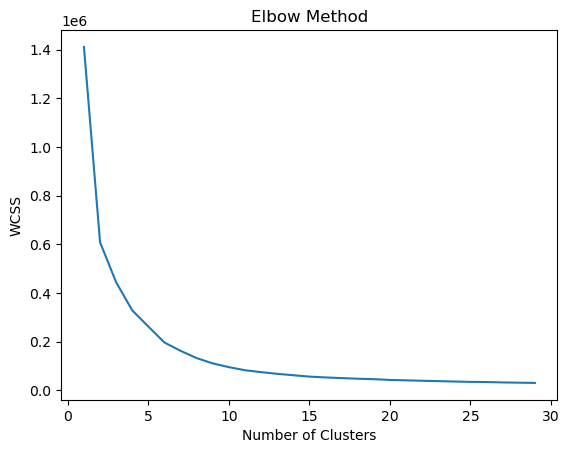

In [69]:
norm_X, scaler = elbow_method(processed_df, columns=['Long', 'Lat', 'Month_Sin', 'Month_Cos'])

## The K-means cluster function again. 

In [70]:
def cluster(data, norm_X, k=7, columns=['Region', 'Month', 'OutageLength'], scale=False):
    dims = len(columns)
    if dims > 3 or dims < 2:
        print("Should be looking at 2 or 3 features, change number of columns evaluated.")

    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    data['clusters'] = kmeans.fit_predict(norm_X)

    fig = plt.figure(figsize=(16, 14))

    # 3d clustering
    if dims == 3:
        ax = fig.add_subplot(111, projection='3d')
    # 2d clustering
    else:
        ax = fig.add_subplot()

    for i in range(k):
        cluster_data = data[data['clusters'] == i]
        if scale:
            sizes = cluster_data['MAGNITUDE']*100
        else:
            sizes = 10
        if dims == 3:
            ax.scatter(cluster_data[columns[0]], cluster_data[columns[1]], cluster_data[columns[2]], label=f'Cluster {i + 1}', edgecolor='black', alpha=0.5, s=sizes/30)
        else:
            ax.scatter(cluster_data[columns[0]], cluster_data[columns[1]], label=f'Cluster {i + 1}', edgecolor='black', alpha=0.5, s=sizes/30)


    ax.set_title('Clusters of Outages')
    ax.set_xlabel(columns[0])
    ax.set_ylabel(columns[1])
    if dims == 3:
        ax.set_zlabel(columns[2])
    lgnd = ax.legend(markerscale=1)
    for handle in lgnd.legend_handles:
        handle.set_sizes([24.0])
    return data, kmeans.cluster_centers_

In [71]:
# Set the number of clusters in this cell. Make sure to activate this cell before you call the function in the cell below. 
k = 7

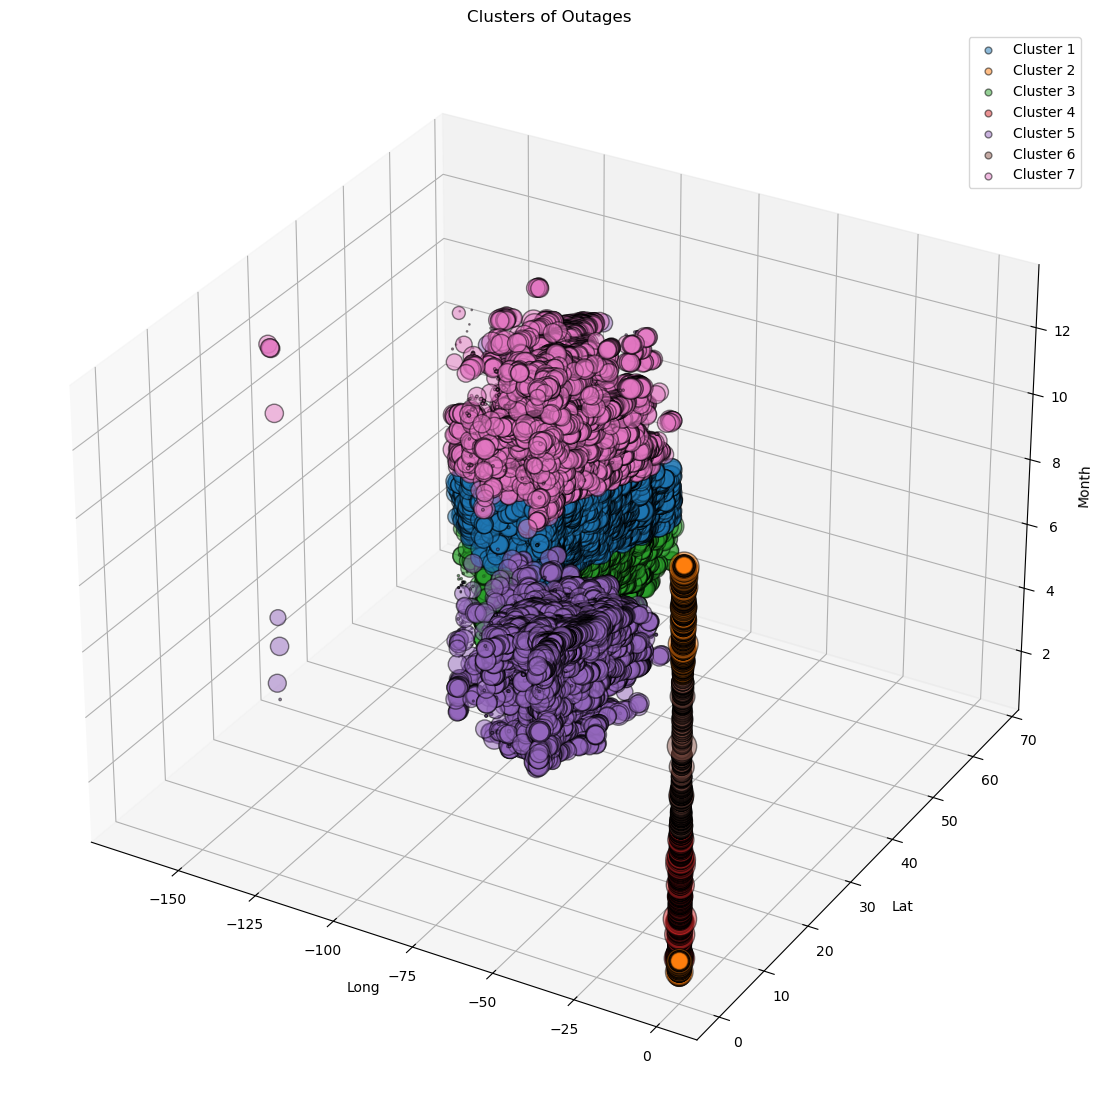

In [72]:
# Call the clustering function
# range_mask = (data['Month'] >= 6.0) & (data['Month'] < 12.0)
new_data, centroids = cluster(processed_df, norm_X, k, columns=['Long', 'Lat', 'Month'], scale=True)

In [74]:
# function that turns our cyclic month coordiates back in to regular months
def revert_comp(sin, cos):
    theta = math.atan2(sin, cos)

    x = 1 + (12 * theta) / (2 * math.pi)

    if x < 1:
        x += 12
    
    return x

In [75]:
# funtion that finds the center of the clsuter -- **the whole point of K-means!**
def centroid_toy(centroids, scaler):
    inversed_centroids = scaler.inverse_transform(centroids)
    for i in range(0, len(inversed_centroids)):
        print(f"Centroid for Cluster {i+1} occurs during time of year: {revert_comp(inversed_centroids[i][2], inversed_centroids[i][3])}")

In [76]:
# CALL THE CENTROID FUCNTION
centroid_toy(centroids, scaler)

Centroid for Cluster 1 occurs during time of year: 7.696153945340121
Centroid for Cluster 2 occurs during time of year: 12.090493282208698
Centroid for Cluster 3 occurs during time of year: 5.864390820165064
Centroid for Cluster 4 occurs during time of year: 2.8685573601414447
Centroid for Cluster 5 occurs during time of year: 3.4322805722474574
Centroid for Cluster 6 occurs during time of year: 7.6387079416530135
Centroid for Cluster 7 occurs during time of year: 10.019169468105497


In [77]:
# Function that slices up the data by month 
def plot_range_slice(data, k, lower, upper, scale=False):
    low_sin, low_cos = circular_toy(lower)
    up_sin, up_cos = circular_toy(upper)
    # print(f'Low Sin: {low_sin}, Low Cos: {low_cos}, High Sin: {up_sin}, High Cos: {up_cos}')
    # date_mask = (new_data['Month'] >= lower) & (new_data['Month'] < upper)
    date_mask = None
    if lower < upper:
        date_mask = (data['Month'] >= lower) & (data['Month'] < upper)
    else:
        date_mask = (data['Month'] >= lower) | (data['Month'] < upper)
    masked_data = data[date_mask]
    # print(masked_data)
    fig = plt.figure(figsize=(12, 10))
    
    ax = fig.add_subplot()

    for i in range(k):
        cluster_data = masked_data[masked_data['clusters'] == i]
        if scale:
            sizes = cluster_data['MAGNITUDE']
        else:
            sizes = 100
        ax.scatter(cluster_data['Long'], cluster_data['Lat'], label=f'Cluster {i+1}', edgecolor='black', alpha=0.5, s=sizes)

    # range_x = masked_data['Long'].max() - masked_data['Long'].min()
    # range_y = masked_data['Lat'].max() - masked_data['Lat'].min()

    # max_range = max(range_x, range_y)

    # mid_x = (masked_data['Long'].max() + masked_data['Long'].min()) / 2
    # mid_y = (masked_data['Lat'].max() + masked_data['Lat'].min()) / 2

    # plt.xlim(mid_x - max_range / 2, mid_x + max_range / 2)
    # plt.ylim(mid_y - max_range / 2, mid_y + max_range / 2)
    
    ax.set_title(f'Clusters of Outages for Time Between Month {lower} and {upper}')
    lgnd = ax.legend(markerscale=1)
    for handle in lgnd.legend_handles:
        handle.set_sizes([24.0])

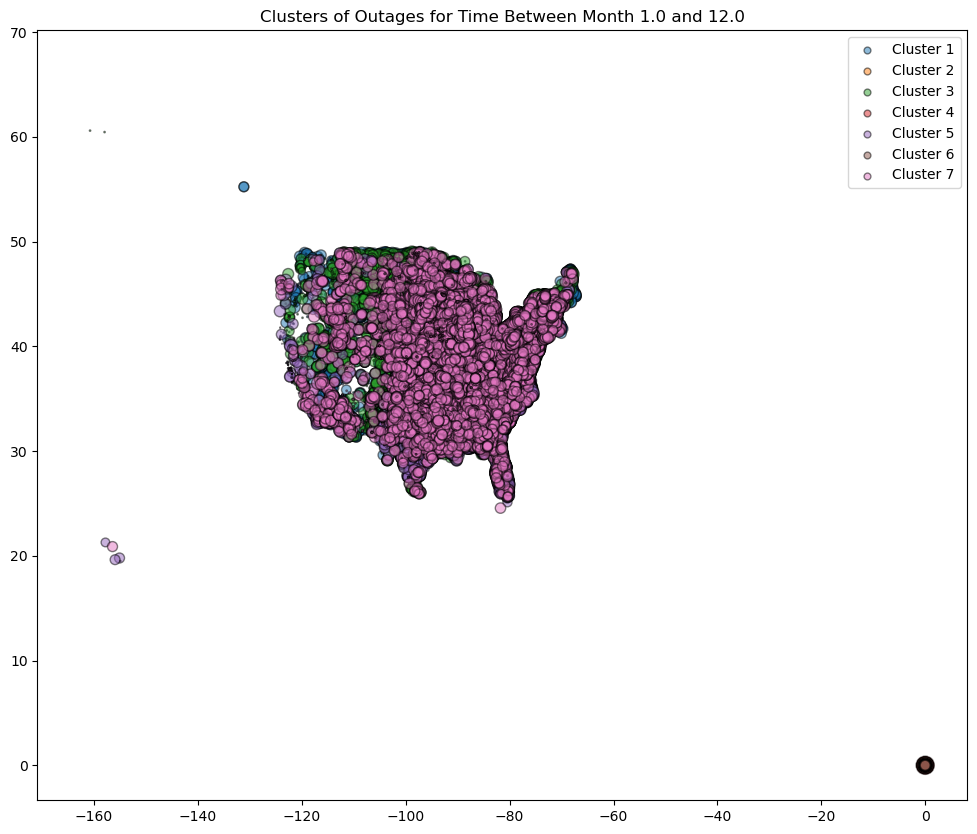

In [78]:
# call the funtion for a slides that is 12 months thick. 
plot_range_slice(processed_df, k, 1.0, 12.0, scale=True)

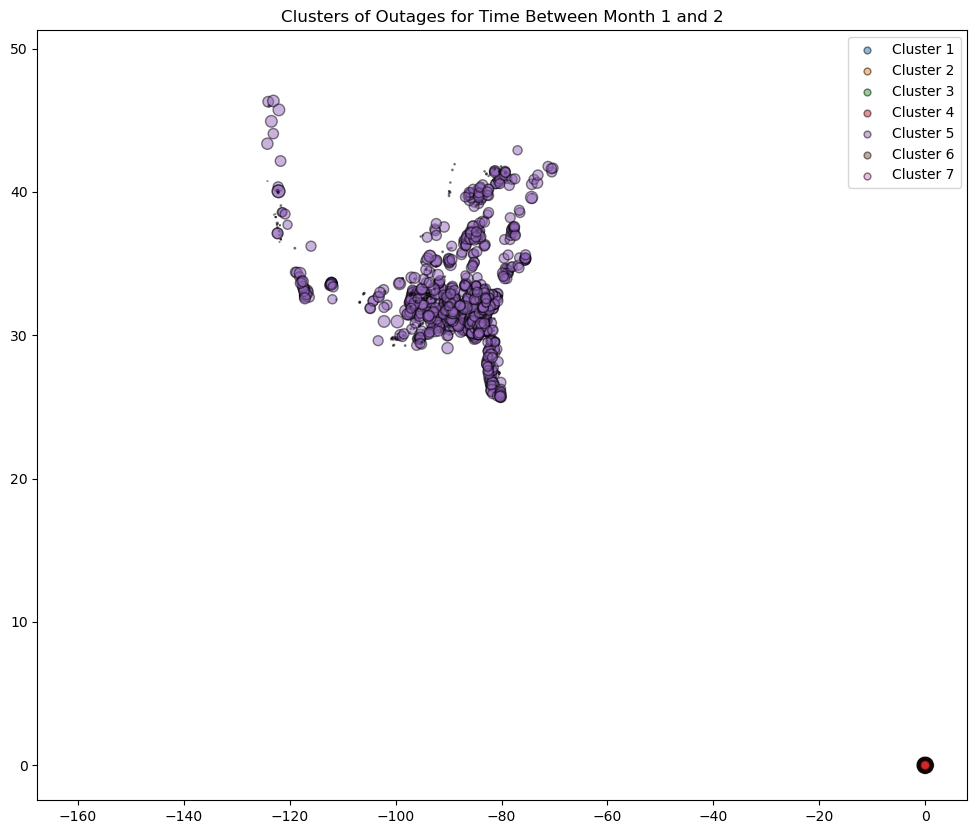

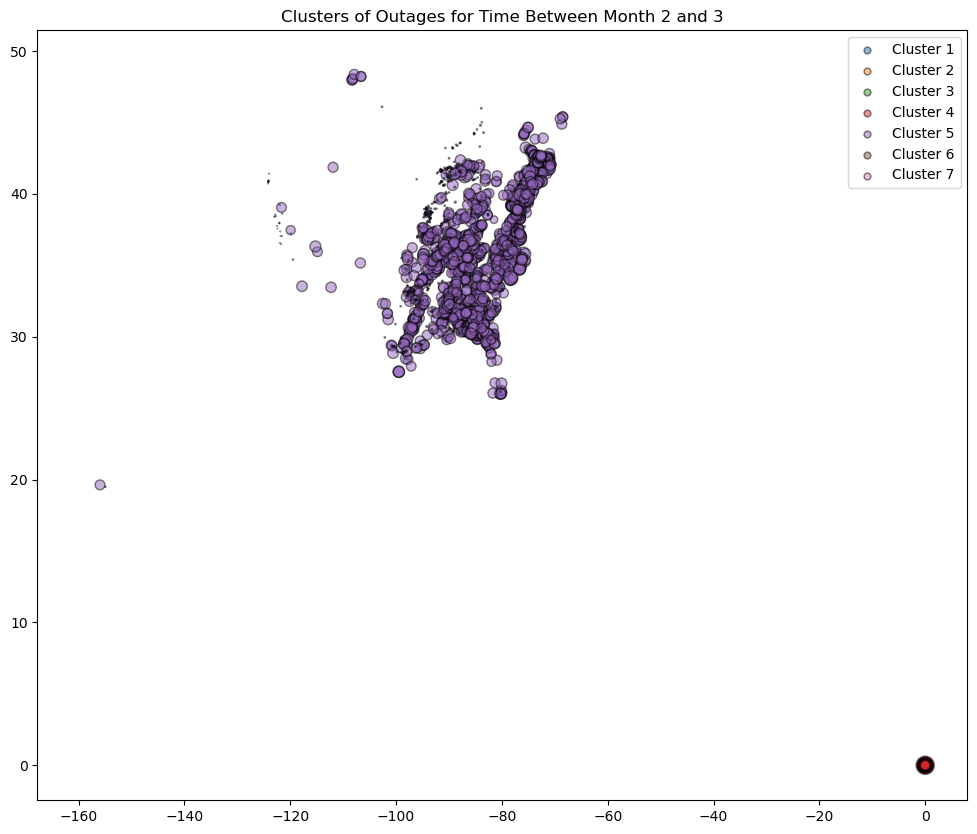

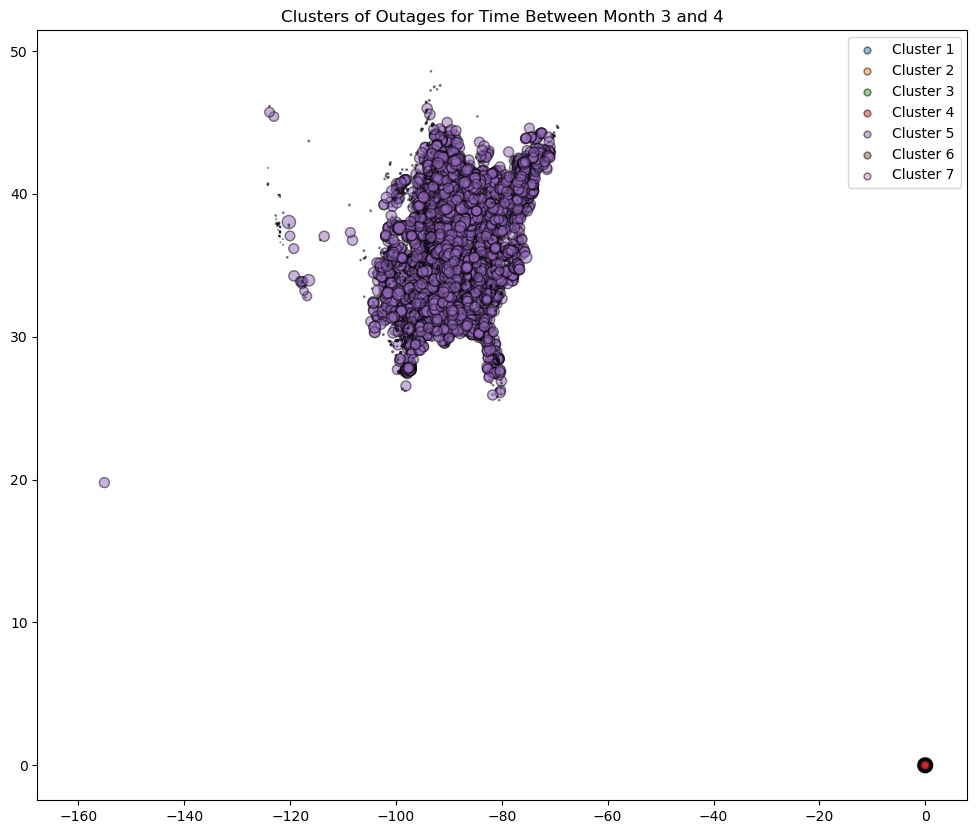

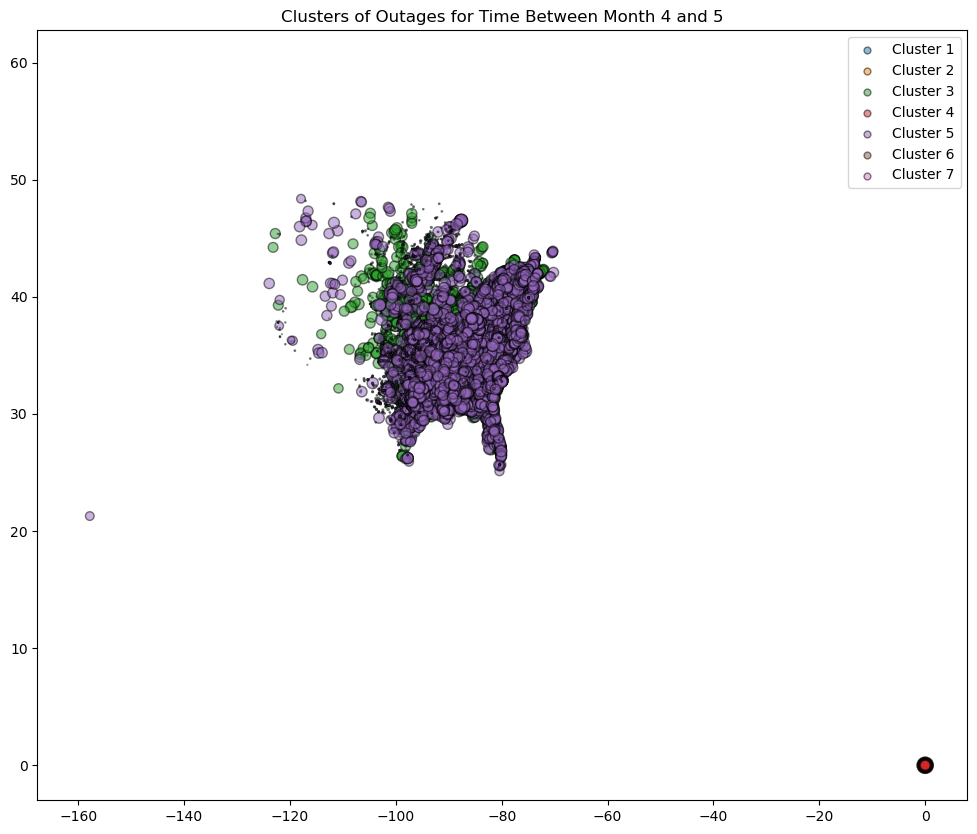

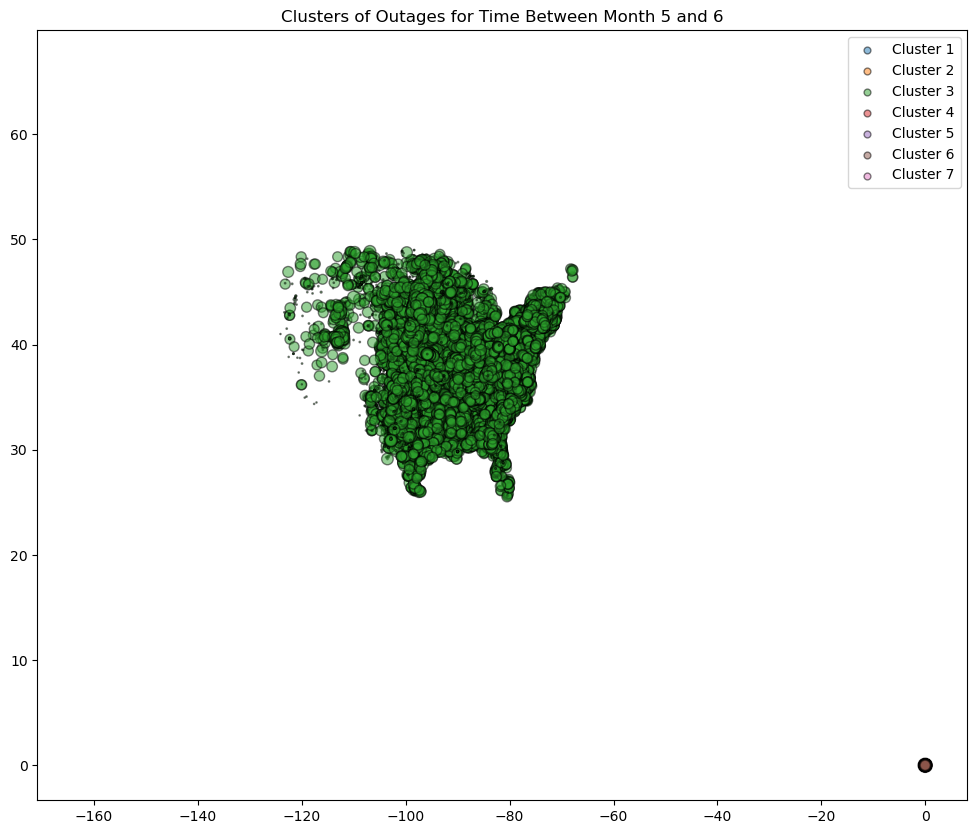

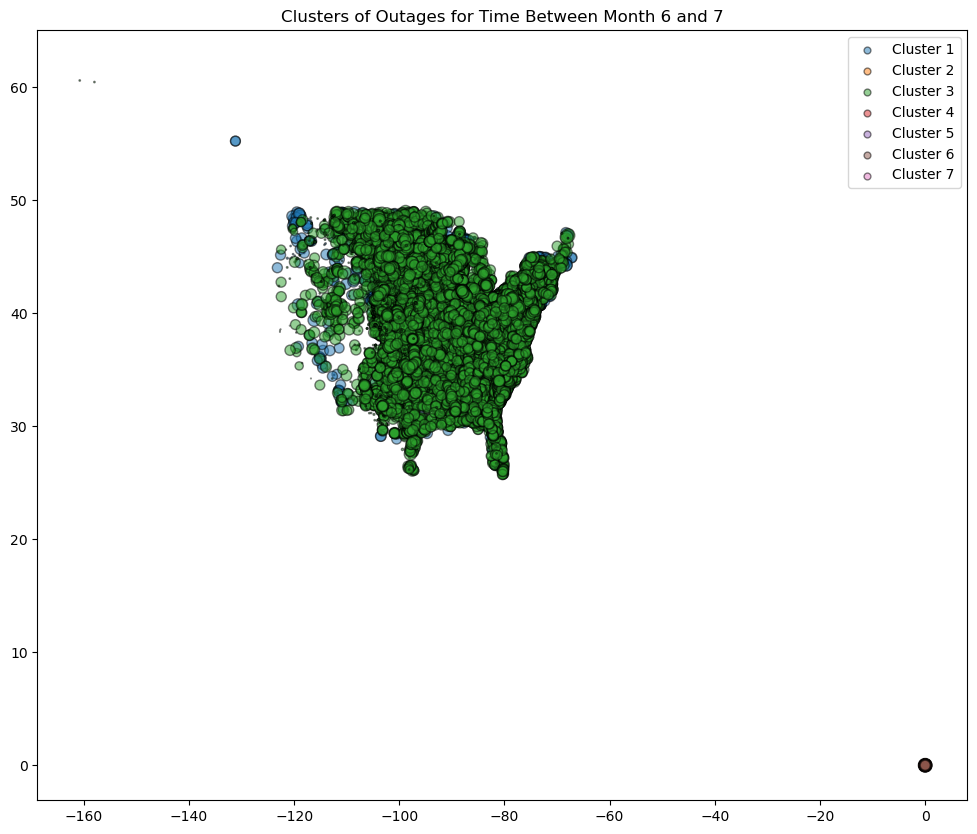

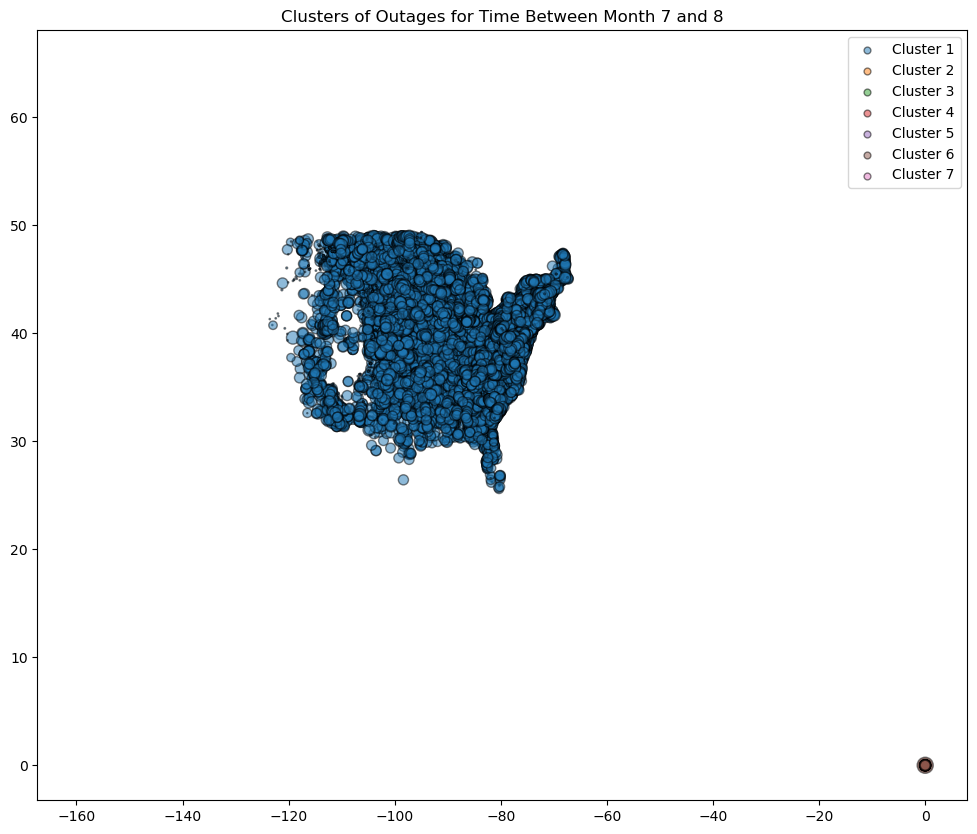

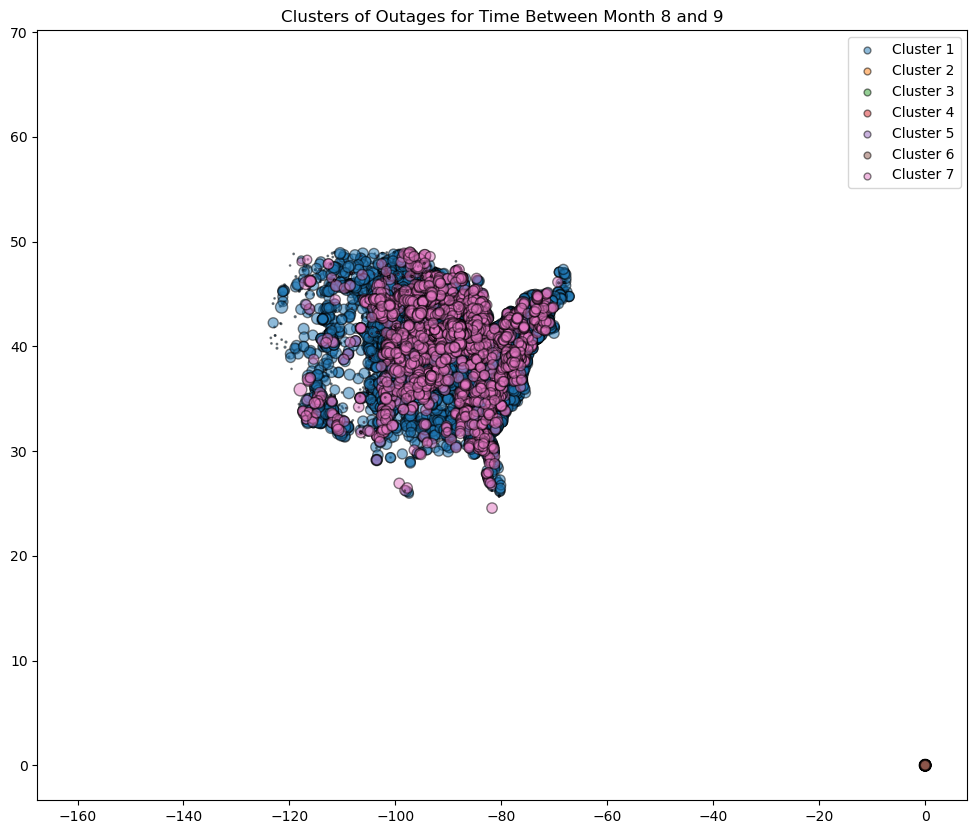

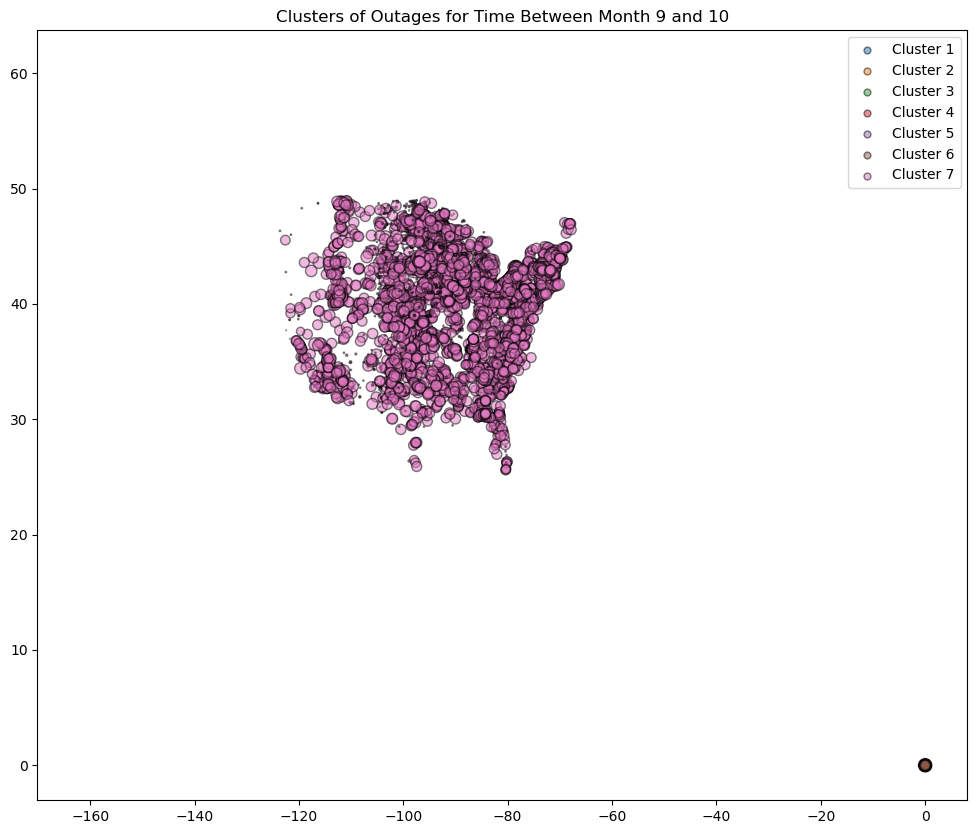

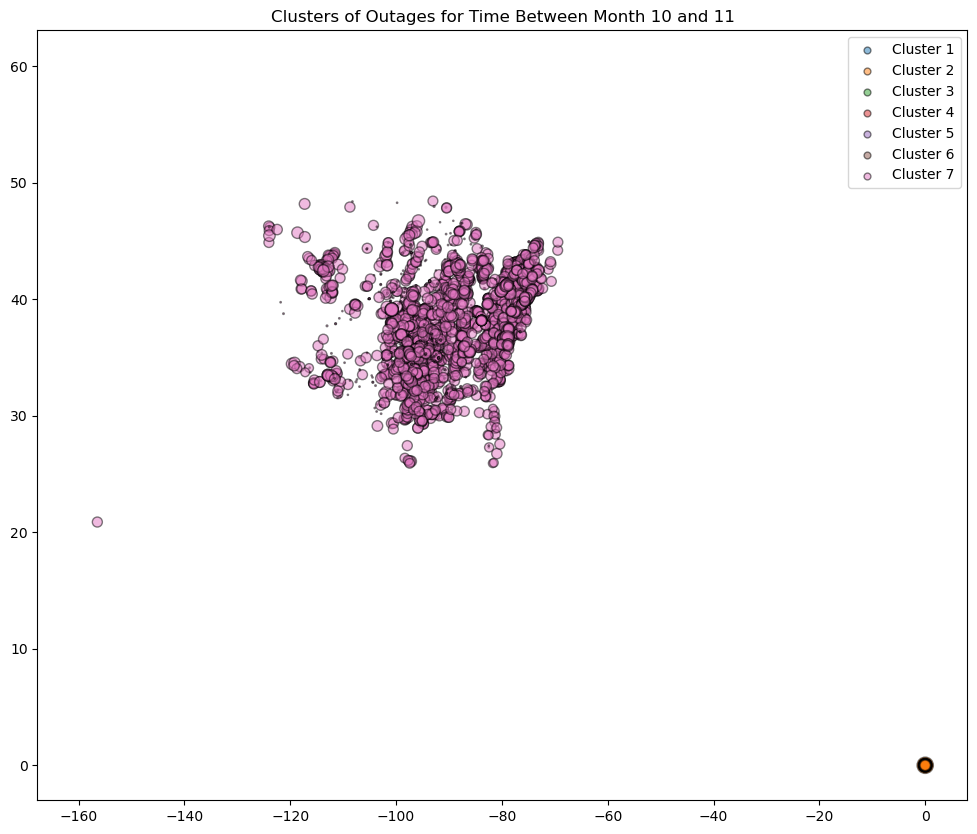

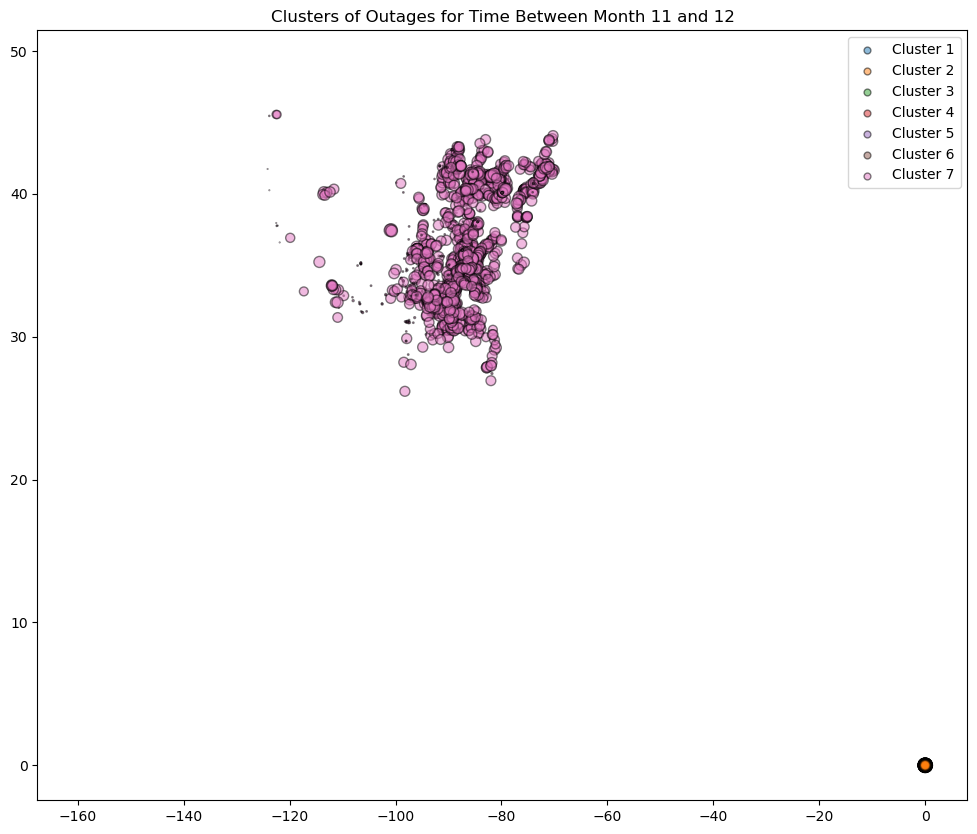

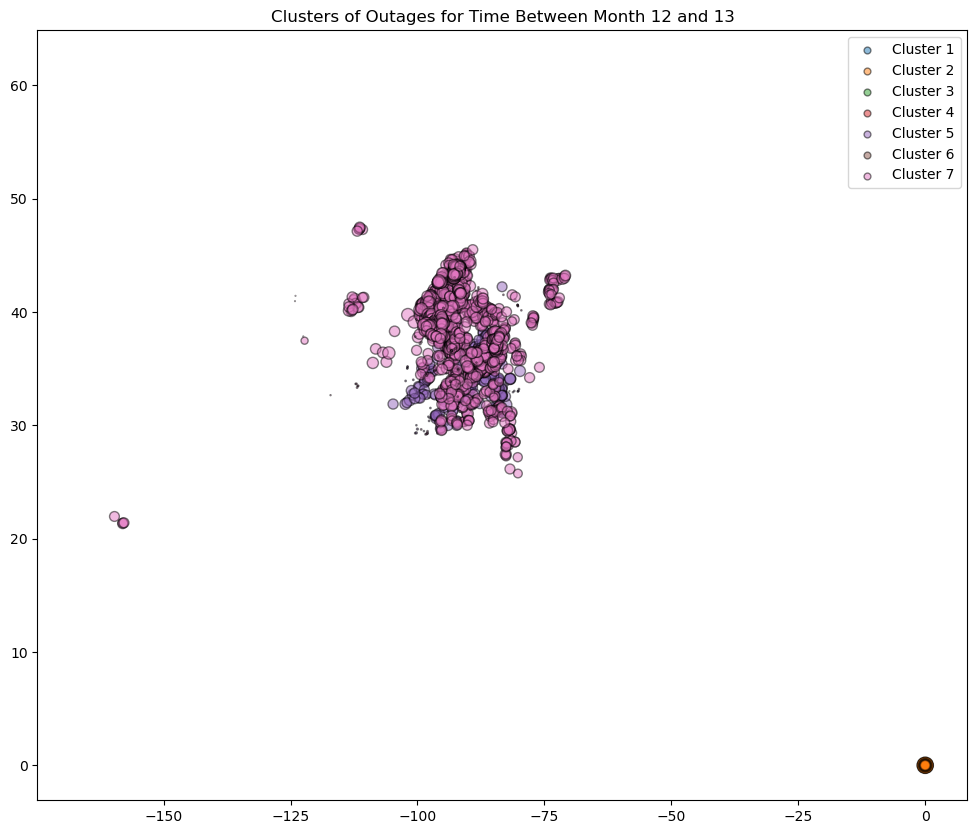

In [79]:
# Call the plot slicer to make a series of 1-month slices
for i in range(1, 13):
    plot_range_slice(new_data, k, i, i + 1, scale=True)
 

# Looking at average number of weather events per month. 
Let's count the number of noteable weather events per month per region.

In [81]:
import numpy as np
import pandas as pd

# Round MONTH to the nearest integer
processed_df['RoundedMonth'] = processed_df['Month'].round()

# Collapse any month 13 into month 12
processed_df.loc[processed_df['RoundedMonth'] == 13, 'RoundedMonth'] = 12

# Count events per Region and RoundedMonth
event_counts = (
    processed_df
    .groupby(['Region', 'RoundedMonth'])
    .size()
    .reset_index(name='EventCount')
)

# Compute average number of events for each Region and RoundedMonth
average_events = (
    event_counts
    .groupby(['Region', 'RoundedMonth'])['EventCount']
    .mean()
    .reset_index(name='AvgEvents')
)

print(average_events)

     Region  RoundedMonth  AvgEvents
0         1           1.0     1858.0
1         1           2.0     3668.0
2         1           3.0     2760.0
3         1           4.0     1551.0
4         1           5.0      926.0
..      ...           ...        ...
103       9           8.0     7719.0
104       9           9.0     4370.0
105       9          10.0     3624.0
106       9          11.0     1838.0
107       9          12.0     2460.0

[108 rows x 3 columns]


# Visualize with Histograms
The code below generates histograms showing the average number of notable weather events per month for each region, based on data averaged across all years.


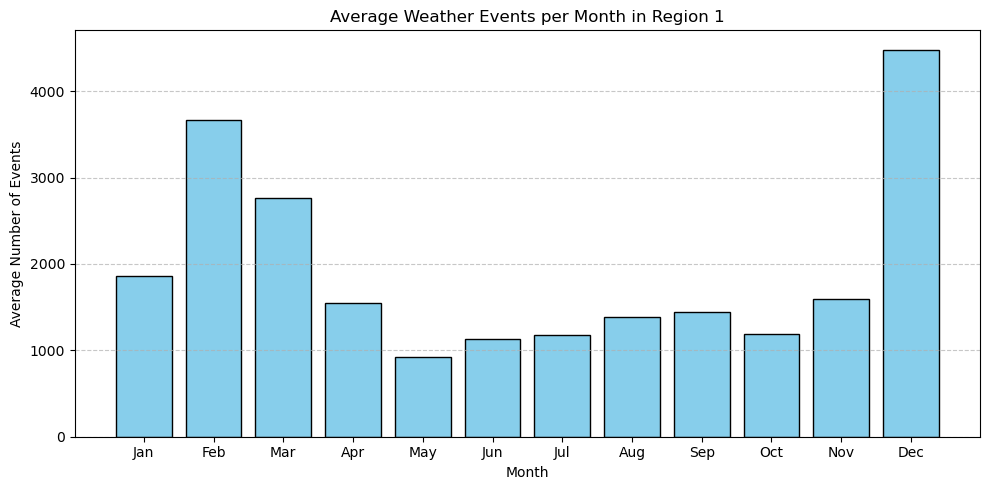

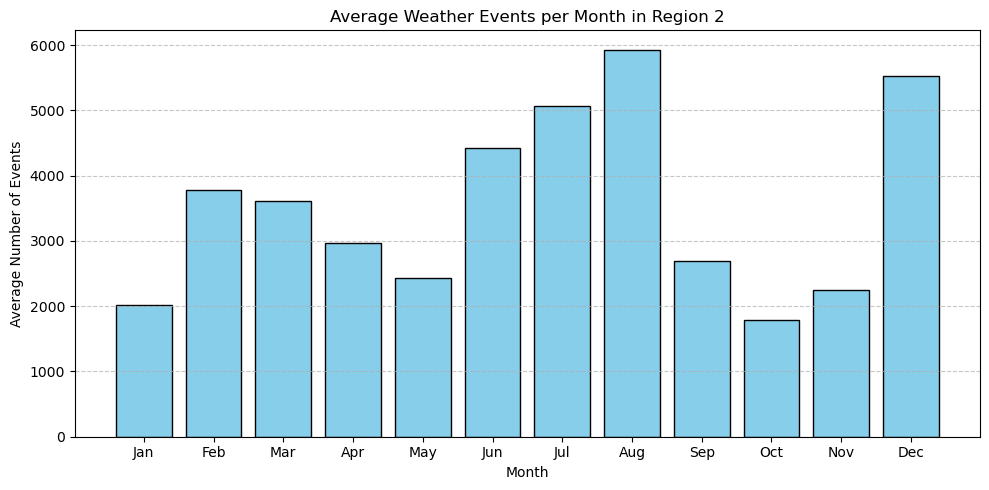

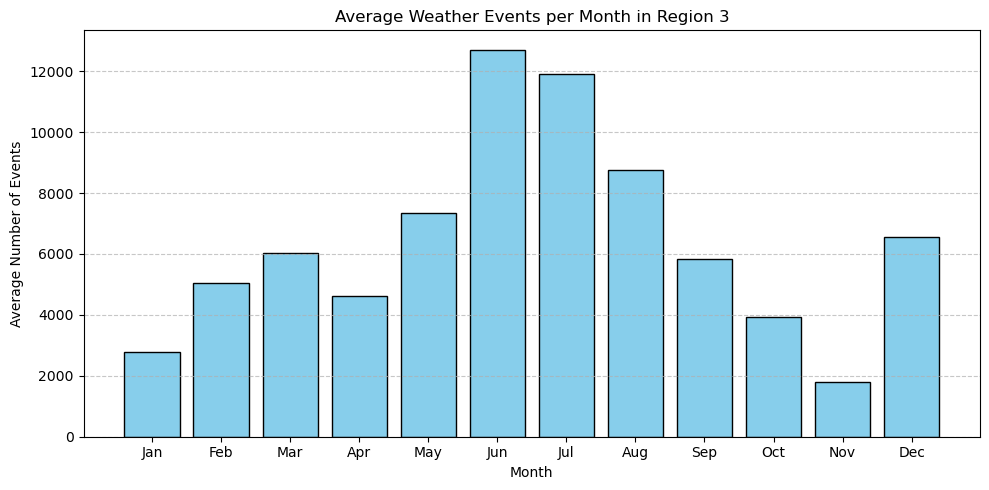

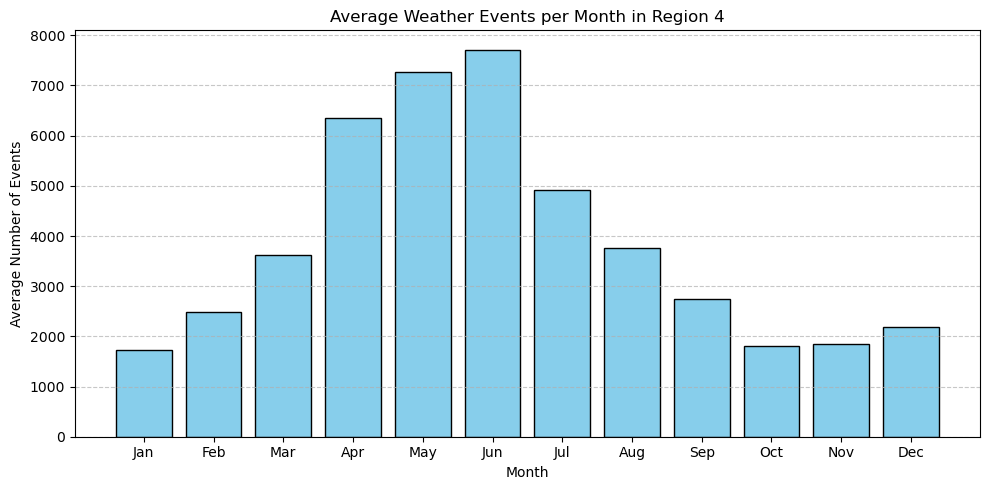

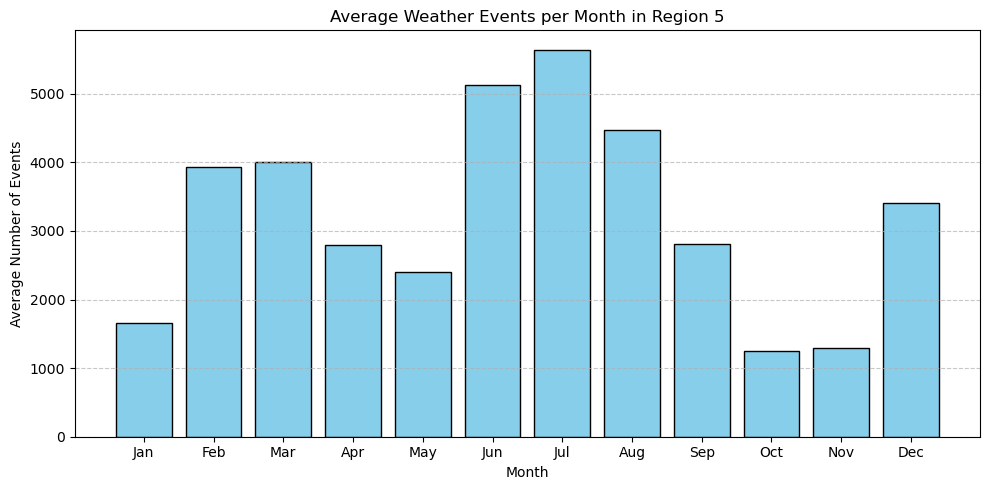

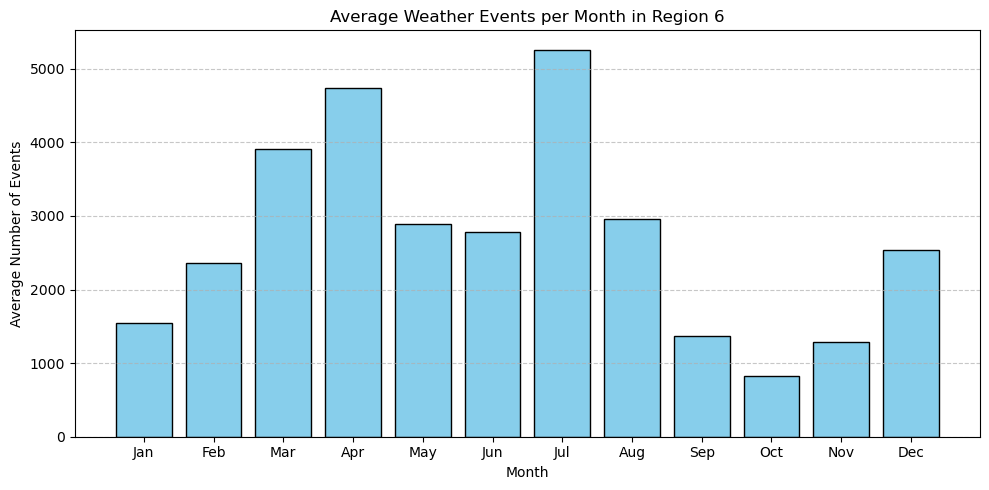

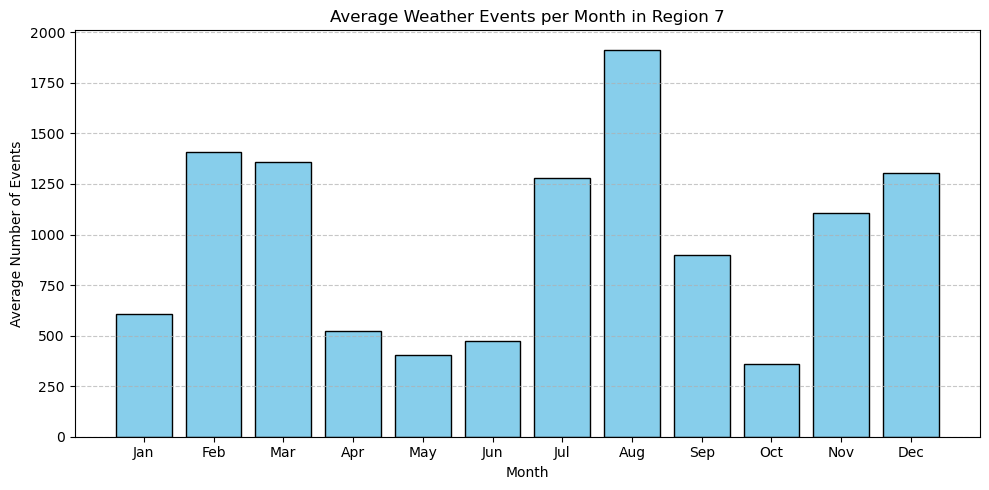

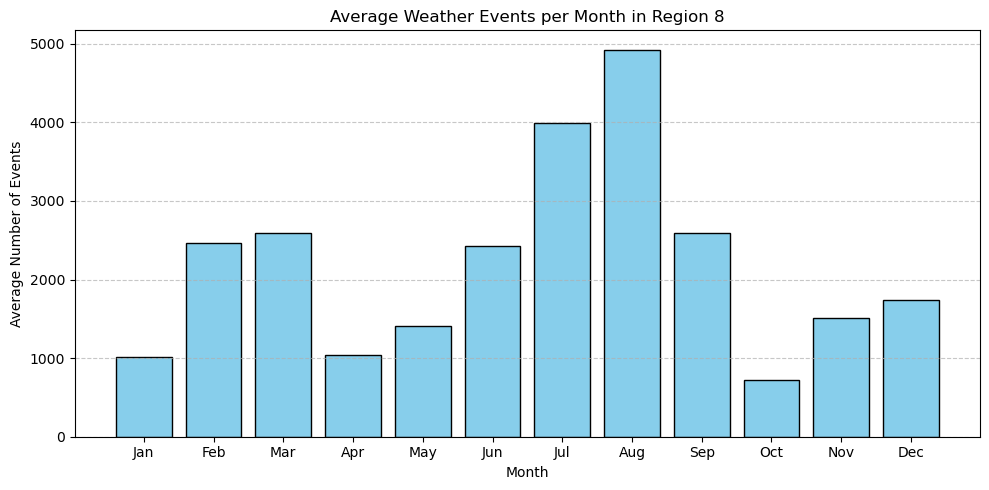

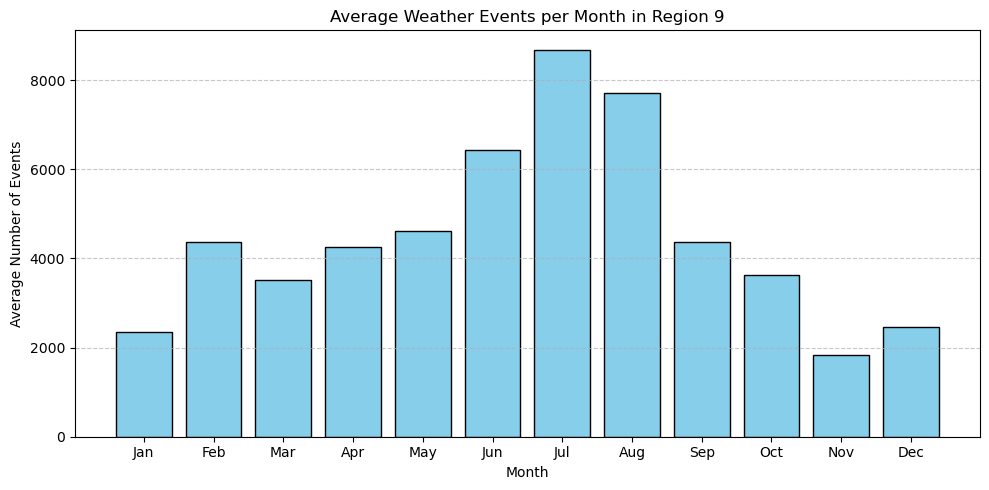

In [83]:
import matplotlib.pyplot as plt

# Get the list of unique regions
regions = average_events['Region'].unique()

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot one histogram per region
for region in regions:
    region_data = average_events[average_events['Region'] == region]
    
    # Sort by month to ensure correct order
    region_data = region_data.sort_values('RoundedMonth')
    
    months = region_data['RoundedMonth']
    averages = region_data['AvgEvents']
    
    plt.figure(figsize=(10, 5))
    plt.bar(months, averages, color='skyblue', edgecolor='black')
    plt.title(f'Average Weather Events per Month in Region {region}')
    plt.xlabel('Month')
    plt.ylabel('Average Number of Events')
    plt.xticks(ticks=range(1, 13), labels=month_labels)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Interpretation of Example

Here’s one way to interpret this unfiltered data:  
The U.S. tends to experience more notable weather in the summer than in the winter.  
Arid regions usually have less dramatic weather than tropical areas.

This analysis can be refined with better characterization of the data:

1. The clustering currently includes *all* notable weather events — but some, like "Dense Fog," are far less likely to cause power outages than others, such as "Hurricanes."
2. Sizing the circle plots by `MAGNITUDE` ends up emphasizing wind events. That’s because only certain event types (like strong wind) consistently receive high magnitude scores in this dataset.  
   Consider either:  
   - using a fixed circle size, or  
   - creating a custom severity score that works across different event types.

### Suggested Next Step

Try filtering the data — see the example function below — and then re-run the analysis. This applies whether you stick with K-means or just use histograms.

You could also experiment with filtering for specific categories, such as:
- All winter storms  
- All hurricanes  
- Only the most severe events (however “severe” is defined)


In [89]:
# Makes a new data frame with just to columns you select- feel free to add or remove any of these given below. 
# You will need to copy this cell into one that is further up in the notebook, Look for the "Hint for Later" 

event_types_to_keep = [
    "Thunderstorm Wind", "Winter Storm", "Flash Flood", "Heavy Snow", "Flood",
    "Excessive Heat", "Tornado", "Heavy Rain", "Strong Wind", "Blizzard",
    "Wildfire", "Lightning", "Tropical Storm", "Ice Storm", "Funnel Cloud",
    "Coastal Flood", "Dust Storm", "Lake-Effect Snow", "Storm Surge/Tide",
    "Avalanche", "Hurricane (Typhoon)", "Tropical Depression", "Dust Devil",
    "Tsunami", "Lakeshore Flood"
]

filtered_df = df_clean[df_clean["EVENT_TYPE"].isin(event_types_to_keep)]

df_clean= filtered_df
df_clean


,EVENT_TYPE,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,MAGNITUDE,EPISODE_NARRATIVE,EVENT_NARRATIVE,BEGIN_DATETIME,END_DATETIME,EVENT_Length
0,Heavy Rain,201607,15,1715,201607,15,1715,108769,651823,SOUTH CAROLINA,45,1.0,N,BOYD HILL,34.9400,-81.0300,34.9400,-81.0300,0.0,Scattered thunderstorms developed across the U...,One to two feet of deep standing water develop...,2016-07-15 17:15:00,2016-07-15 17:15:00,0.000000
1,Thunderstorm Wind,201607,15,1725,201607,15,1725,108769,651825,SOUTH CAROLINA,45,1.0,S,FT MILL,35.0100,-80.9300,35.0100,-80.9300,50.0,Scattered thunderstorms developed across the U...,NWS Columbia relayed a report of trees blown d...,2016-07-15 17:25:00,2016-07-15 17:25:00,0.000000
2,Thunderstorm Wind,201607,16,1246,201607,16,1246,108812,651828,NORTH CAROLINA,37,2.0,ENE,OLD FT,35.6400,-82.1400,35.6400,-82.1400,50.0,Scattered thunderstorms developed near the Blu...,Media reported two trees blown down along I-40...,2016-07-16 12:46:00,2016-07-16 12:46:00,0.000000
3,Thunderstorm Wind,201607,8,1755,201607,8,1755,105872,635287,TENNESSEE,47,1.0,W,JENA,35.6500,-84.1800,35.6500,-84.1800,50.0,The combination of summer heating and high low...,Numerous trees were reported down in the Green...,2016-07-08 17:55:00,2016-07-08 17:55:00,0.000000
4,Thunderstorm Wind,201607,8,1810,201607,8,1810,105872,635296,TENNESSEE,47,1.0,WSW,PITNER,35.8700,-83.7700,35.8700,-83.7700,60.0,The combination of summer heating and high low...,Numerous trees were reported down in Seymour. ...,2016-07-08 18:10:00,2016-07-08 18:10:00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370552,Thunderstorm Wind,202204,5,0626,202204,5,0626,168351,1025113,MISSISSIPPI,28,1.0,NNE,BLUNTS,32.4162,-89.0457,32.4162,-89.0457,50.0,A low pressure system moving east along the Ar...,A tree was blown down near the intersection of...,2022-04-05 06:26:00,2022-04-05 06:26:00,0.000000
370553,Winter Storm,202212,23,0100,202212,24,1600,179346,1092395,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area ar...,2022-12-23 01:00:00,2022-12-24 16:00:00,1.625000
370554,Winter Storm,202212,23,0100,202212,24,1600,179346,1092399,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area sh...,2022-12-23 01:00:00,2022-12-24 16:00:00,1.625000
370555,Winter Storm,202212,23,0200,202212,24,1600,179346,1092402,OHIO,39,0.0,0,0,0.0000,0.0000,0.0000,0.0000,0.0,"A long-duration, multi-faceted winter storm hi...",An Arctic cold front swept through the area ar...,2022-12-23 02:00:00,2022-12-24 16:00:00,1.583333


# Project Part 3: Weather Correlation

## TO DO:  
- Use the K-means clustering in this notebook, histograms , or another methods to explore the relationship between weather patterns and power outage patterns.  
- Support your conclusions with plots and charts for the final presentation.
- You many want to save a copy of this notebook for refrence before you make changes. 
